# 03a. Azure Public Dataset V2 — Predictive Analysis - Feature Engineering

**Part**: A. Feature Engineering

**Authors:** Fajar Laksono

**Methodology:** CRISP-ML(Q) + CAMS DevOps

**Last Updated:** 2026-05-12


---

## 0. Table of Contents

1. [1. Preparation](#1.-preparation)
    - [1.1. Import Libraries](#1.1.-import-libraries)
    - [1.2. Load Dataset](#1.2.-load-datasets)
    - [1.3. QA: Data Quality Gate](#1.3.-qa-data-quality-gate)
2. [2. Feature Engineering](#2.-feature-engineering)
    - [2.1. Target Variable Definition](#2.1.-target-variable-definition)
    - [2.2. Feature Construction](#2.2.-feature-construction)
    - [2.3. QA: Feature Validation Gate](#2.3.-qa-feature-validation-gate)
    - [2.4. Feature Summary](#2.4.-feature-summary)
    - [2.5. Correlation & Mutual Information Analysis](#2.5.-correlation--mutual-information-analysis)
    - [2.6. Feature Selection & Train-Test Split](#2.6.-feature-selection--train-test-split)
    - [2.7. Save Artifact](#2.7.-save-artifact)


## 1. Preparation

**CRISP-ML(Q) Phase:** Data Understanding

### 1.1. Import Libraries

In [1]:
import os, sys, warnings, pathlib
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
warnings.filterwarnings('ignore')
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
import os
from pathlib import Path
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
DATA_DIR = Path(os.getenv('DATA_DIR', 'data/transformed/parquet'))
if not DATA_DIR.is_absolute():
    DATA_DIR = (PROJECT_ROOT / DATA_DIR).resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from app.src.features import create_features, get_feature_target_columns
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully.')


All libraries imported successfully.


### 1.2. Load Datasets

In [2]:
# DATA_DIR now from .env (see first cell)

con = duckdb.connect(':memory:')

# Register views for all tables
for tbl in ['vmtable', 'subscriptions', 'deployments', 'azure_pricing']:
    path = DATA_DIR / f'{tbl}.parquet'
    if path.exists():
        con.execute(f"CREATE VIEW {tbl} AS SELECT * FROM read_parquet('{path}')")
        count = con.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
        print(f'  \u2713 {tbl}: {count:,} rows')
    else:
        print(f'  \u2717 {tbl}: not found')

# Load main vmtable
vmtable = con.execute('SELECT * FROM vmtable').fetchdf()
print(f'\u2713 vmtable loaded: {len(vmtable):,} rows, {len(vmtable.columns)} columns')

# Load pricing for rate_per_hour lookup
pricing_df = None
if (DATA_DIR / 'azure_pricing.parquet').exists():
    pricing_df = con.execute('SELECT * FROM azure_pricing').fetchdf()
    print(f'\u2713 pricing_df loaded: {len(pricing_df):,} rows')

# Load subscriptions for subscription-level features
subscriptions_df = None
if (DATA_DIR / 'subscriptions.parquet').exists():
    subscriptions_df = con.execute('SELECT * FROM subscriptions').fetchdf()
    print(f'\u2713 subscriptions_df loaded: {len(subscriptions_df):,} rows')

# Load deployments for deployment-level features
deployments_df = None
if (DATA_DIR / 'deployments.parquet').exists():
    deployments_df = con.execute('SELECT * FROM deployments').fetchdf()
    print(f'\u2713 deployments_df loaded: {len(deployments_df):,} rows')

# Quick preview
display(vmtable.head(3))


  ✓ vmtable: 2,695,548 rows
  ✓ subscriptions: 6,687 rows
  ✓ deployments: 33,205 rows
  ✓ azure_pricing: 9 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ vmtable loaded: 2,695,548 rows, 11 columns
✓ pricing_df loaded: 9 rows
✓ subscriptions_df loaded: 6,687 rows
✓ deployments_df loaded: 33,205 rows


,vm_id,subscription_id,deployment_id,timestamp_created,timestamp_deleted,max_cpu,avg_cpu,p95_max_cpu,vm_category,vm_core_count_bucket,vm_memory_gb_bucket
0,71fJw0x+SDRdAxKPwLyHZhTgQpYw2afS6tjJhfT6kHnmLH...,GB6uQC1NSArW5n+TtOybL7GQ1yByjuWtZnsj+5QccZ525R...,2sh/ZjaYdfpslv4iYBfNzFe4rs982kHVvNGJGeQ8MIBCDr...,558300,1673700,91.776885,0.728879,20.759630,Delay-insensitive,8,32
1,rKggHO/04j31UFy65mDTwtjdMQL/G03xWfl3xGeiilB4/W...,ub4ty8ygwOECrIz7eaZ/9hDwnCsERvZ3nJJ03sDSpD85et...,+ZraIDUNaWYDZMBiBtZm7xSjr+j3zcHGjup1+wyKxHFmyJ...,424500,425400,37.879261,3.325358,37.879261,Unknown,4,32
2,YrR8gPtBmfNaOdnNEW5If1SdTqQgGQHEnLHGPjySt53bKW...,9LrdYRcUfGbmL2fFfLR/JUg2OTkjGRe3iluwIhDRPnPDPa...,GEyIElfPSFupze8T+T1niQMepeqG88VpLNuxUMyIDbz8VF...,1133100,1133700,0.304368,0.220553,0.304368,Unknown,4,32


### 1.3. QA: Data Quality Gate

In [3]:
# ---------------------------------------------------------------------------
# DATA QUALITY GATE — CRISP-ML(Q) Quality Assurance
# Fail fast if input data is empty, missing required columns, or has no rows.
# ---------------------------------------------------------------------------
assert len(vmtable) > 0, "FAIL: Empty vmtable — cannot proceed"
assert vmtable['vm_id'].nunique() > 0, "FAIL: No unique VMs found"

REQUIRED_COLS = {'vm_id', 'avg_cpu', 'max_cpu', 'p95_max_cpu',
                 'vm_category', 'vm_core_count_bucket', 'vm_memory_gb_bucket'}
missing_cols = REQUIRED_COLS - set(vmtable.columns)
assert not missing_cols, f"FAIL: Missing required columns: {missing_cols}"

null_rate = vmtable[list(REQUIRED_COLS & set(vmtable.columns))].isnull().sum().sum()
print(f"[OK] Data quality: {len(vmtable):,} rows, {vmtable['vm_id'].nunique():,} unique VMs, "
      f"{null_rate} nulls in required columns")

if null_rate > 0:
    print("  ⚠ Warning: nulls detected — consider imputation strategy")
else:
    print("  [OK] No nulls in required columns")

[OK] Data quality: 2,695,548 rows, 2,695,548 unique VMs, 0 nulls in required columns
  [OK] No nulls in required columns


## 2. Feature Engineering

**CRISP-ML(Q) Phase:** Data Preparation

**Thin import:** `app.src.features`

### 2.1. Target Variable Definition

**Business Question:** What targets best capture cloud resource waste and cost optimization opportunities?

| Task | Type | Target | Business Goal |
|---|---|---|---|
| Utilization regression | Regression | `avg_cpu` | Predict actual CPU usage |
| Waste regression | Regression | `waste_fraction = 1 - (avg_cpu / 100)` | Quantify waste per VM |
| Cost regression | Regression | `vm_cost = rate_per_hour \times lifetime` | Forecast cloud spend |
| Idle detection | Binary classification | `is_idle = 1 if avg_cpu < 5%` | Flag wasted VMs |
| Waste tier | Multi-class | `waste_tier`: Low (<10%), Medium (10-50%), High (>50%) | Prioritize optimization |

In [4]:
# Target definitions (computed inside create_features):
# - is_idle: avg_cpu < 5%
# - waste_fraction: 1 - (avg_cpu / 100), clipped [0, 1]
# - waste_tier: Low (<10%), Medium (10-50%), High (>50%)
# - vm_cost: lifetime_hours * rate_per_hour (if pricing data available)
print('Target variables defined in app.src.features.create_features()')


Target variables defined in app.src.features.create_features()


### 2.2. Feature Construction

**Business Question:** What engineered features best capture VM resource usage patterns?

**Approach:** Call `create_features()` from `app.src.features` which performs:
- Parse `vm_core_count_bucket` and `vm_memory_gb_bucket` to numeric values
- Calculate `lifetime_hours` from creation/deletion timestamps
- Cyclical encoding of `creation_hour` and `creation_dayofweek` (sin/cos)
- Ratio features: `cpu_per_core`, `memory_per_core`, `burstiness`, `max_to_avg_ratio`
- Binary flags: `is_short_lived` (lifetime < 1 hour)
- One-hot encoding of `vm_category`, `vm_core_count_bucket`, `vm_memory_gb_bucket`
- Target variables: `is_idle`, `waste_fraction`, `waste_tier`, `vm_cost`

In [5]:
# Apply feature engineering with all data sources
features_df = create_features(vmtable, pricing_df,
                               subscriptions_df, deployments_df)


### 2.3. QA: Feature Validation Gate

In [6]:
# ---------------------------------------------------------------------------
# FEATURE VALIDATION GATE — CRISP-ML(Q) Quality Assurance
# Verify engineered features contain expected columns with valid ranges.
# ---------------------------------------------------------------------------
TARGET_COLS = ['is_idle', 'waste_tier', 'waste_fraction']
FEATURE_COLS = ['core_count', 'memory_gb', 'lifetime_hours', 'cpu_per_core',
                'burstiness', 'is_short_lived', 'creation_hour_sin', 'creation_hour_cos']

for col in TARGET_COLS:
    assert col in features_df.columns, f"FAIL: Missing target column '{col}'"

for col in FEATURE_COLS:
    assert col in features_df.columns, f"FAIL: Missing feature column '{col}'"

# Range checks
assert features_df['waste_fraction'].min() >= -1e-6, "FAIL: waste_fraction < 0"
assert features_df['waste_fraction'].max() <= 1.0 + 1e-6, "FAIL: waste_fraction > 1"
assert set(features_df['waste_tier'].cat.categories) == {'Low', 'Medium', 'High'},     "FAIL: waste_tier categories incorrect"
assert features_df['is_idle'].dtype == bool, "FAIL: is_idle must be boolean"

# Cyclical encoding bounds
for col in ['creation_hour_sin', 'creation_hour_cos', 'creation_dow_sin', 'creation_dow_cos']:
    if col in features_df.columns:
        assert features_df[col].min() >= -1.0 - 1e-6, f"FAIL: {col} < -1"
        assert features_df[col].max() <= 1.0 + 1e-6, f"FAIL: {col} > 1"

print(f"[OK] Features validated: {len(features_df):,} rows, "
      f"{len(features_df.columns)} columns, "
      f"{features_df.isnull().sum().sum()} total nulls")

[OK] Features validated: 2,695,548 rows, 47 columns, 0 total nulls


### 2.4. Feature Summary

| Feature | Type | Derivation |
|---------|------|-----------|
| `core_count` | numeric | Parse bucket: 2→2, 4→4, 8→8, 24→24, >24→48 |
| `memory_gb` | numeric | Parse bucket: 4→4, 8→8, 32→32, 64→64, >64→128 |
| `lifetime_hours` | numeric | (timestamp_deleted - timestamp_created) / 3600 |
| `creation_hour_sin/cos` | cyclic | sin(2πh/24), cos(2πh/24) |
| `creation_dow_sin/cos` | cyclic | sin(2πd/7), cos(2πd/7) |
| `cpu_per_core` | ratio | avg_cpu / core_count |
| `memory_per_core` | ratio | memory_gb / core_count |
| `burstiness` | ratio | p95_max_cpu / (avg_cpu + 1e-6) |
| `max_to_avg_ratio` | ratio | max_cpu / (avg_cpu + 1e-6) |
| `is_short_lived` | binary | lifetime_hours < 1 |
| `cat_*`, `core_*`, `mem_*` | one-hot | pd.get_dummies() |

### 2.5. Correlation & Mutual Information Analysis

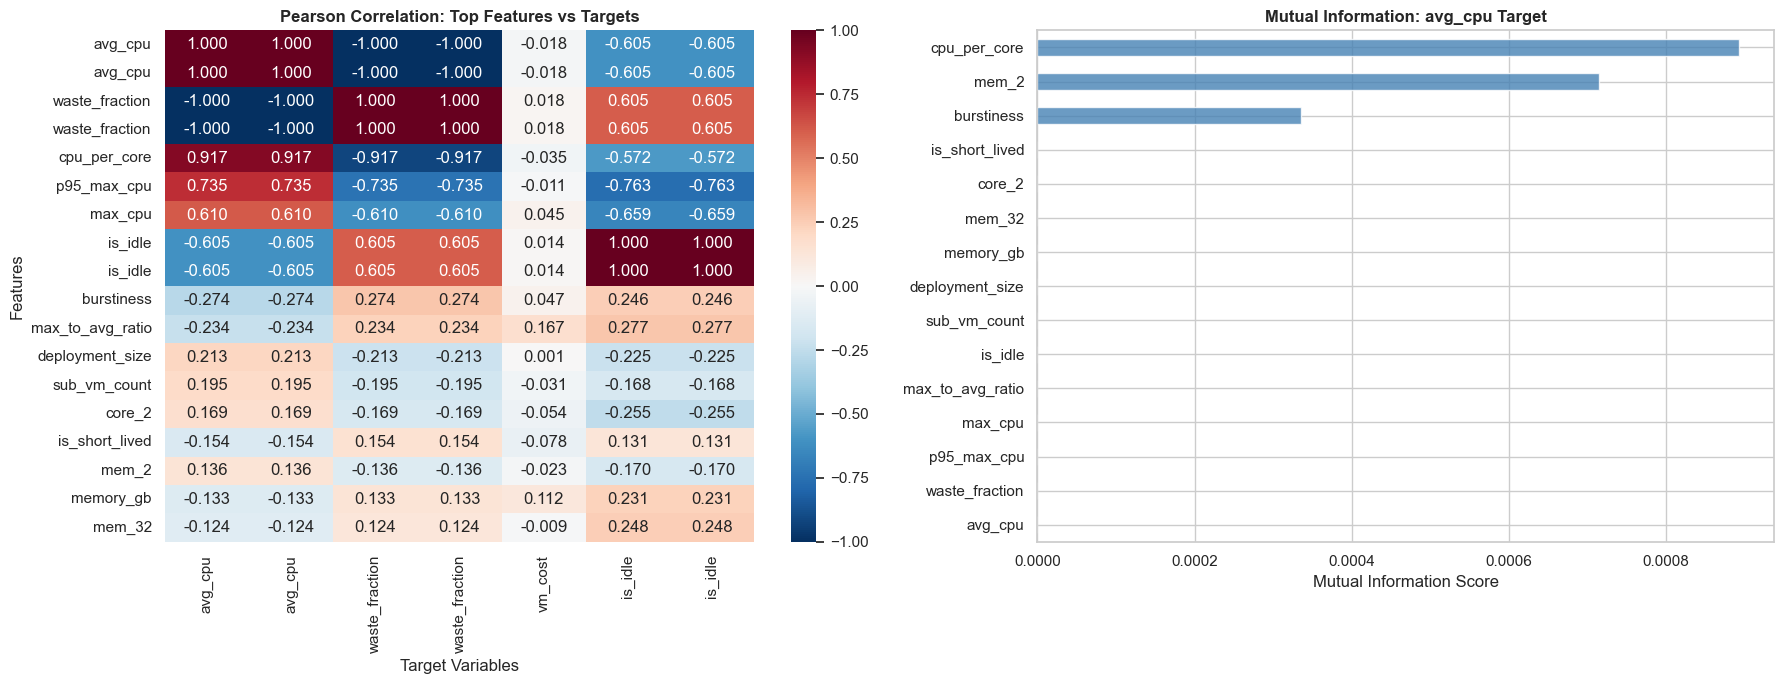


Key Findings:
  - Top-3 features by correlation: ['waste_fraction', 'cpu_per_core', 'p95_max_cpu']
  - Top-3 features by MI: ['burstiness', 'mem_2', 'cpu_per_core']


In [7]:
# Sample 100k rows for correlation/MI analysis to avoid MemoryError
sample_df = features_df.sample(n=100_000, random_state=RANDOM_STATE)
numeric_df = sample_df.select_dtypes(include=[np.number, bool])
target_cols = ['avg_cpu', 'waste_fraction', 'vm_cost', 'is_idle']

# Correlation heatmap for top features per target
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson correlation with avg_cpu
corr_with_cpu = numeric_df.corrwith(features_df['avg_cpu'], method='pearson').abs().sort_values(ascending=False)
top_cpu_features = corr_with_cpu.head(15).index.tolist()

# Heatmap: top features vs targets
corr_matrix = numeric_df[top_cpu_features + target_cols].corr(method='pearson')
sns.heatmap(corr_matrix.loc[top_cpu_features, target_cols],
            annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0])
axes[0].set_title('Pearson Correlation: Top Features vs Targets', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target Variables')
axes[0].set_ylabel('Features')

# Mutual Information scores
from sklearn.feature_selection import mutual_info_regression

# Sample 100k rows to avoid MemoryError on 2.7M rows\n",
rng = np.random.RandomState(RANDOM_STATE)
mi_sample_idx = rng.choice(len(numeric_df), size=100_000, replace=False)
mi_X = numeric_df[top_cpu_features].fillna(0).iloc[mi_sample_idx]
mi_y = features_df['avg_cpu'].iloc[mi_sample_idx]

mi_scores = mutual_info_regression(mi_X, mi_y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=top_cpu_features).sort_values(ascending=True)

mi_series.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Mutual Information: avg_cpu Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mutual Information Score')

plt.tight_layout()
plt.show()

print('\nKey Findings:')
print(f'  - Top-3 features by correlation: {corr_with_cpu.index[1:4].tolist()}')
print(f'  - Top-3 features by MI: {mi_series.index[-3:].tolist()}')

### 2.6. Feature Selection & Train-Test Split

In [8]:
# Get feature and target columns for our primary task
features, target = get_feature_target_columns('regression_avg_cpu')

# Select available feature columns (only those that exist in features_df)
available_features = [c for c in features if c in features_df.columns]
print(f'Available features ({len(available_features)}): {available_features}')

# Prepare feature matrix and target vector
X = features_df[available_features].select_dtypes(include=[np.number]).copy()
y_cpu = features_df['avg_cpu'].values
y_idle = features_df['is_idle'].astype(int).values
y_waste = features_df['waste_fraction'].values
y_tier = features_df['waste_tier'].cat.codes.values  # 0=Low, 1=Medium, 2=High

# Stratified split by waste_tier to preserve class balance
X_train, X_test, y_cpu_train, y_cpu_test = train_test_split(
    X, y_cpu, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_idle_train, y_idle_test = train_test_split(
    X, y_idle, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_waste_train, y_waste_test = train_test_split(
    X, y_waste, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_tier_train, y_tier_test = train_test_split(
    X, y_tier, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Features:     {X_train.shape[1]}')
print(f'\nWaste tier distribution in train:')
tier_dist = pd.Series(y_tier_train).value_counts().sort_index()
for code, count in tier_dist.items():
    label = ['Low', 'Medium', 'High'][code]
    print(f'  {label}: {count:,} ({count/len(y_tier_train)*100:.1f}%)')

Available features (15): ['core_count', 'memory_gb', 'lifetime_hours', 'memory_per_core', 'is_short_lived', 'rate_per_hour', 'sub_vm_count', 'sub_tenure', 'deployment_size', 'creation_hour_sin', 'creation_hour_cos', 'creation_dow_sin', 'creation_dow_cos', 'max_cpu', 'p95_max_cpu']
Training set: 2,156,438 samples
Test set:     539,110 samples
Features:     14

Waste tier distribution in train:
  Low: 1,751 (0.1%)
  Medium: 159,713 (7.4%)
  High: 1,994,974 (92.5%)


### 2.7. Save Artifact

In [9]:
# === Save artifact for 03b and 03c ===
features_df.to_parquet(DATA_DIR / 'features_df.parquet')
print(f'\n\u2713 Artifact saved: {DATA_DIR / "features_df.parquet"}')


✓ Artifact saved: D:\Project\Github\FajarLaksono\sembada-cloud\data\transformed\parquet\features_df.parquet
